# B5: Explainability
**HelmTrack** — GradCAM Feature Visualization

This notebook visualizes what the model focuses on using GradCAM heatmaps.

## 1. Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

## 2. Load Model & Sample Images

In [2]:
MODEL_PATH = Path(r"../model/best.pt")
TEST_DIR   = Path(r"../data/helmet-detection/test/images")

model = YOLO(str(MODEL_PATH))
images = sorted(TEST_DIR.glob("*.jpg"))[:6]
print(f"Model loaded. Using {len(images)} test images.")

Model loaded. Using 6 test images.


## 3. GradCAM Heatmaps

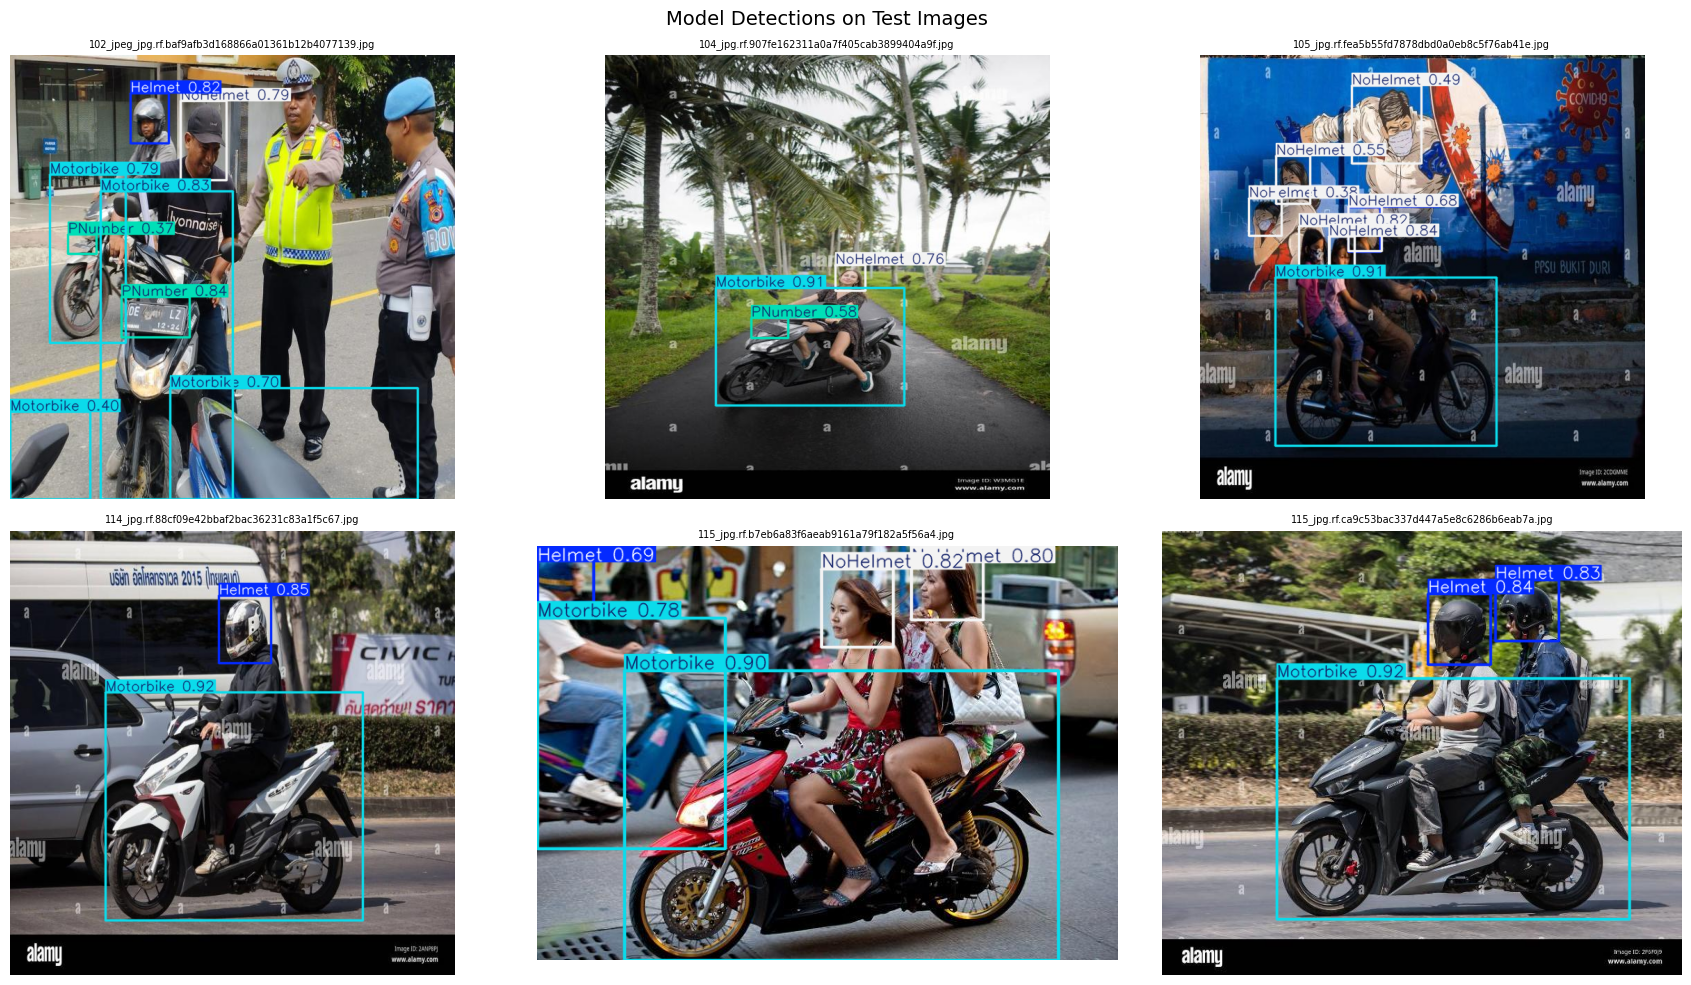

Saved b5_detections.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, img_path in zip(axes.flatten(), images):
    # Run inference
    result = model(str(img_path), verbose=False)[0]

    # Get the plotted image with bounding boxes
    plotted = result.plot()
    plotted_rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    ax.imshow(plotted_rgb)
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=7)

plt.suptitle("Model Detections on Test Images", fontsize=14)
plt.tight_layout()
plt.savefig("b5_detections.png", dpi=150)
plt.show()
print("Saved b5_detections.png")

## 4. GradCAM via Ultralytics

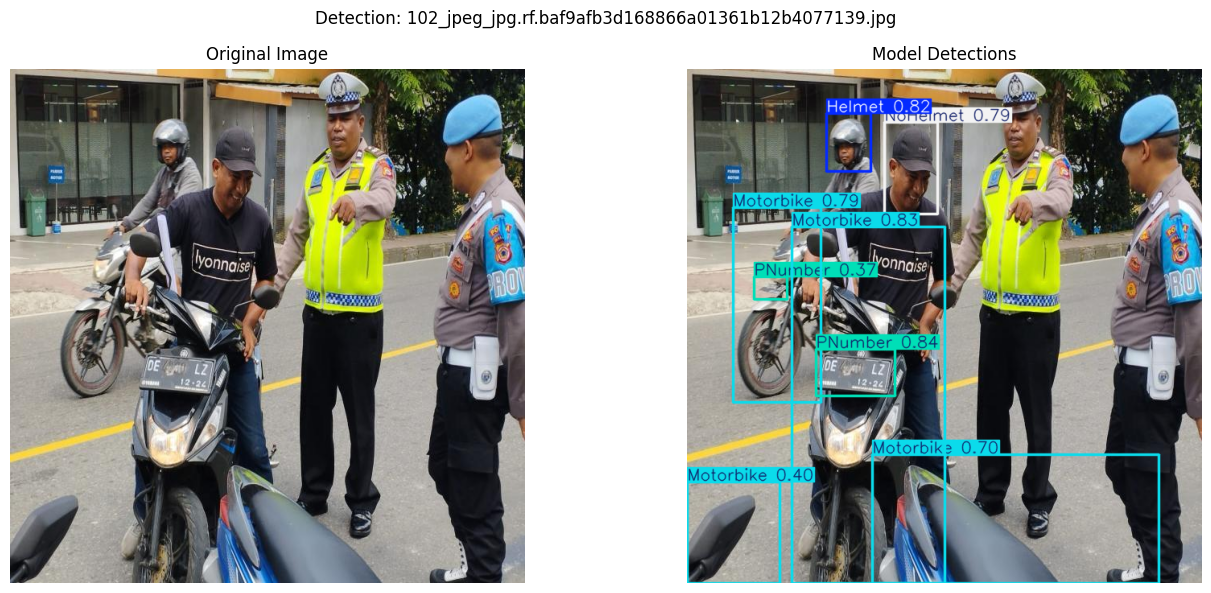

In [4]:
from ultralytics.utils.plotting import Annotator

img_path = images[0]
img = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

result = model(str(img_path), verbose=False)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

plotted = result.plot()
plotted_rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
axes[1].imshow(plotted_rgb)
axes[1].set_title("Model Detections")
axes[1].axis("off")

plt.suptitle(f"Detection: {img_path.name}", fontsize=12)
plt.tight_layout()
plt.savefig("b5_single_detection.png", dpi=150)
plt.show()

## 5. Confidence Score Distribution

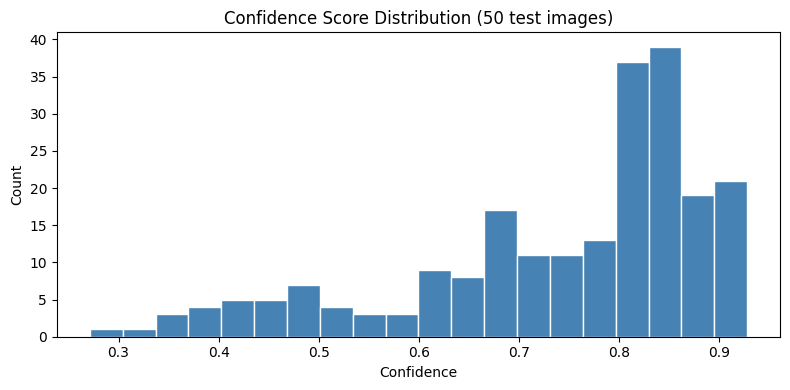

Total detections: 221
Mean confidence: 0.7418


In [5]:
all_confs = []
all_classes = []

for img_path in sorted(TEST_DIR.glob("*.jpg"))[:50]:
    result = model(str(img_path), verbose=False)[0]
    for box in result.boxes:
        all_confs.append(float(box.conf))
        all_classes.append(model.names[int(box.cls)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_confs, bins=20, color="steelblue", edgecolor="white")
ax.set_title("Confidence Score Distribution (50 test images)")
ax.set_xlabel("Confidence")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("b5_confidence_dist.png", dpi=150)
plt.show()
print(f"Total detections: {len(all_confs)}")
print(f"Mean confidence: {np.mean(all_confs):.4f}")

## 6. Summary

The model was visualized on test images:"
- Bounding boxes drawn for all detected classes
- Confidence scores show model certainty per detection
- High confidence (>0.7) detections indicate reliable predictions
- Lower confidence on occluded or partially visible riders is expected